In [29]:
# This notebook integrates ocean color data in Google Earth Engine (GEE) with animal telemetry data that is NOT in GEE.
# To get the track data into GEE, I converted it from csv to pandas DataFrame to geopandas GeoDataFrame to GEE FeatureClass.
# The integrated data is visualized as an animation using the time_slider.

# GEE's time_slider can animate a single layer. Therefore, the challenge is to combine the following into a single layer:
# a) The static track (i.e. all the points that comprise the track);
# b) The time-varying location along the track i.e. the animal's location per frame;
# c) The time-varing SST i.e. for each frame, show the snapshot of (daily) SST for the same day as (b)

# To combine these 3 together, we use the Image.blend() method--per frame. However, this only works on raster images.
# Items (a) and (b) above are vector-based, and (c) is raster. So, before I can blend the 3 items together (per frame), I have to convert
# the vector-based items (feature classes) to images. 

# Another challenge to overcome is the display. The HYCOM SST is a single band image.
# For single-band images, the "palette" is used to define how band values get translated into colors
# So, when I convert the vector-based items (feature classes) to images, I'll also need to reduce them to a single band AND 
# make sure the value of that single band shows up well in the display relative to the SST, given the palette. That's a lot!

#-Apply filterBounds to collection i.e. the roi--why isn't this working? Need to clip?


In [66]:
# Imports
import ee
import geemap
import geemap.colormaps as cm
import geedim
import pandas as pd
import geopandas as gpd
import movingpandas as mpd
from shapely.geometry import Point
from datetime import datetime, timedelta
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Custom import from a different folder
import sys
sys.path.append('../project')
import project_functions

ModuleNotFoundError: No module named 'project_functions'

In [3]:
ee.Authenticate()

True

In [57]:
m1 = geemap.Map()

In [58]:
# ROI
roi = ee.Geometry.BBox(-50.0, 35.0, -10.0, 62.0)
m1.center_object(roi)
m1    

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [59]:
# A function that returns a single ocean color image, given a date
# Caller must fix scale and offset
def single_ocean_color_image(this_timestamp_datetime,roi):
    # Ocean color collection
    collection = (ee.ImageCollection('COPERNICUS/MARINE/SATELLITE_OCEAN_COLOR/V6')
        .filter(ee.Filter.date("2019-02-01","2019-08-01"))
        .select('chlor_a')
        .filter(ee.Filter.bounds(roi))          
    )
    # return first image from the collection, scaled and offset to degrees C
    first_image = collection.first()
    #return first_image.multiply(0.001).add(20.0)
    # For some reason, the caller has trouble with max<min when I include the scaling and offset here;
    # therefore, let the caller apply the scaling and offset in the vis_params
    return first_image

In [60]:
# Use vis params bounds that work for ocean color image
# For single-band images, the palette is used to define how band values get translated into colors
min_val = 0
max_val = 1
vis_params_ocean_color = {
  "min": min_val,
  "max": max_val,
  "palette": ['blue', 'purple', 'cyan', 'green', 'yellow', 'red'],
}

# Javascript example from https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_MARINE_SATELLITE_OCEAN_COLOR_V6#code-editor-javascript
#var dataset = ee.ImageCollection('COPERNICUS/MARINE/SATELLITE_OCEAN_COLOR/V6')
#                  .filter(ee.Filter.date('2024-06-01', '2024-07-01'));
#var chlorA = dataset.select('chlor_a');
#var chlorAVis = {
#  min: 0,
#  max: 1,
#  palette: ['blue', 'purple', 'cyan', 'green', 'yellow', 'red'],
#};

In [65]:
# Test function before putting it in the loop
this_timestamp_datetime = datetime(2019,2,15)
this_image = single_ocean_color_image(this_timestamp_datetime,roi)

m1.add_layer(this_image, vis_params_ocean_color, "test_ocean_color_image")
m1

Map(bottom=6780.0, center=[35.17380831799959, -74.87182617187501], controls=(WidgetControl(options=['position'…

In [56]:
roi


ee.Geometry({
  "functionInvocationValue": {
    "functionName": "GeometryConstructors.Polygon",
    "arguments": {
      "coordinates": {
        "constantValue": [
          [
            [
              -50.0,
              62.0
            ],
            [
              -50.0,
              35.0
            ],
            [
              -10.0,
              35.0
            ],
            [
              -10.0,
              62.0
            ]
          ]
        ]
      },
      "geodesic": {
        "constantValue": false
      }
    }
  }
})

In [86]:
# Load animal track csv into pandas dataframe
input_csv_folder = 'C:/Users/s44ba/Documents/Training/Northeastern/AdvSpatialAnalysis/Project/Data/fromSeabirdTrackingNetwork/'
input_csv_filename = 'Dataset_1044__Black-legged_Kittiwake_Grumant_GLS_2009_2010_2011.csv'
#input_csv_filename = 'Dataset_1038__Black-legged_Kittiwake_Anda_GLS_2009_2010_2011.csv'
#input_csv_filename = 'Dataset_1041__Black-legged_Kittiwake_Bulbjerg_GLS_2009_2010_2011.csv'
#input_csv_filename = 'Dataset_1043__Black-legged_Kittiwake_Faroe_Islands_GLS_2009_2010.csv'
#input_csv_filename = 'Dataset_1049__Black-legged_Kittiwake_Kippaku_GLS_2008_2009_2010_2011.csv'
input_csv_fullpath = input_csv_folder + input_csv_filename
df = pd.read_csv(input_csv_fullpath)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5437 entries, 0 to 5436
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   dataset_id         5437 non-null   int64  
 1   scientific_name    5437 non-null   object 
 2   common_name        5437 non-null   object 
 3   site_name          5437 non-null   object 
 4   colony_name        5437 non-null   object 
 5   lat_colony         5437 non-null   float64
 6   lon_colony         5437 non-null   float64
 7   device_type        5437 non-null   object 
 8   bird_id            5437 non-null   int64  
 9   track_id           5437 non-null   object 
 10  original_track_id  5437 non-null   object 
 11  age                5437 non-null   object 
 12  sex                5437 non-null   object 
 13  breed_stage        5437 non-null   object 
 14  breed_status       5437 non-null   object 
 15  date_gmt           5437 non-null   object 
 16  time_gmt           5437 

In [87]:
# Convert to datetime
# Add new column, derived timestamp_datetime, initialized to 1/1/1970
df["timestamp_datetime"] = datetime(1970,1,1)
# Convert
format_string = "%Y-%m-%d %H:%M:%S"
for k in range(len(df)):
    date_string = df.loc[k,"date_gmt"]
    time_string = df.loc[k,"time_gmt"]
    datetime_string = date_string + ' ' + time_string
    df.loc[k,"timestamp_datetime"] = datetime.strptime(datetime_string,format_string)
#endfor

In [88]:
# Fewer columns
df_subset = df[['bird_id','timestamp_datetime','longitude','latitude']]


In [89]:
# Convert to geopandas
geometry = gpd.points_from_xy(df_subset['longitude'],df_subset['latitude'])
gdf_subset = gpd.GeoDataFrame(df_subset,geometry=geometry,crs="EPSG:4326")


In [90]:
# Before converting to movingpandas, we need to set index to timestamp_datetime
gdf_subset.set_index('timestamp_datetime')
print(gdf_subset.head())


   bird_id  timestamp_datetime  longitude  latitude                   geometry
0    13103 2009-08-22 11:02:00   21.04393  73.71249  POINT (21.04393 73.71249)
1     8840 2009-08-22 22:30:00   19.84599  74.89249  POINT (19.84599 74.89249)
2    13103 2009-08-22 22:46:00   18.93946  74.53732  POINT (18.93946 74.53732)
3    13103 2009-08-23 10:30:00   22.18571  75.17378  POINT (22.18571 75.17378)
4     8840 2009-08-23 10:46:00   21.73195  75.41312  POINT (21.73195 75.41312)


In [91]:
# Show unique bird ids
unique_bird_ids = gdf_subset["bird_id"].unique()
print(unique_bird_ids)

[13103  8840  8855 13124 13117 13110  8860 13112 13076 13099 13093 13104
 13084  8850 13085 13113]


<Axes: xlabel='bird_id'>

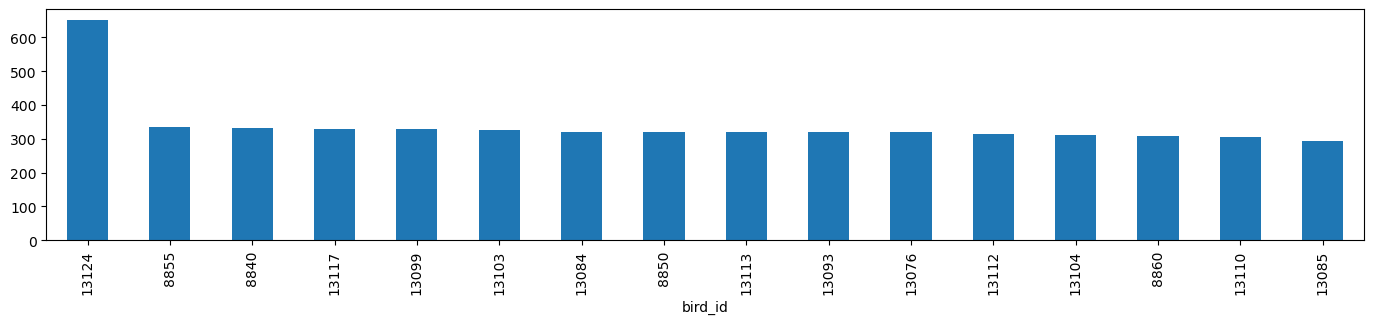

In [96]:
# How many records per unique id?
df["bird_id"].value_counts().plot(kind="bar", figsize=(17, 3))

In [97]:
# Convert to movingpandas
this_bird_id = 13124        
traj = mpd.Trajectory(gdf_subset, this_bird_id, traj_id_col='bird_id', t='timestamp_datetime')
traj.add_speed(overwrite=True)
print(traj.df.describe())

       bird_id    longitude     latitude         speed
count   5143.0  5143.000000  5143.000000   5143.000000
mean   13124.0   -24.089223    58.105461   1732.979659
std        0.0    31.794726    11.271527   3431.328910
min    13124.0   -67.857930    33.000180      0.036196
25%    13124.0   -45.977780    49.995735    229.193439
50%    13124.0   -36.961460    53.544960    536.951902
75%    13124.0   -16.671230    68.127885   1557.469594
max    13124.0    74.133590    82.775130  39465.319091


<Axes: >

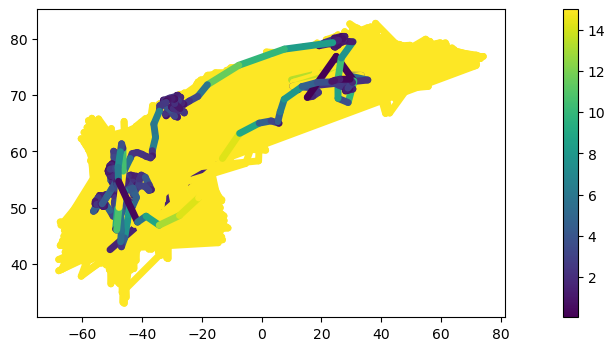

In [103]:
# Plot speed
traj.plot(column="speed", linewidth=5, capstyle="round", figsize=(15, 4), legend=True, vmax=15)

In [6]:
# Get a single animal track as a pandas DataFrame

# Specify fullpath to input csv file containing multiple animal tracks
# i.e. the csv downloaded from movebank.org and load it into a pandas DataFrame
track_csv_fullpath = '../../project_data/track_data/Short_finned_pilot_whales_CRC_NW_Atlantic.csv'

# Let's look at just one of the tracks. From data exploration, I found GmTag142 to be 
# interesting i.e. it went through my region of interest
tag_id = 'GmTag142'  # e.g. 'GmTag142' or 'GmTag137'

# Call function to get the individual track, as pandas dataframe
myTrack = project_functions.get_movebank_track_from_csv(track_csv_fullpath, tag_id)

# Subset myTrack in time
myTrack_in_time_window = myTrack['timestamp_datetime']<datetime(2016,1,6)   # boolean
myTrack_subset = myTrack[myTrack_in_time_window]

# Reset index
myTrack_subset.reset_index()

NameError: name 'project_functions' is not defined

In [8]:
# Convert track from pandas DataFrame to geopandas GeoDataFrame
# First, specify geometry
geometry_myTrack = gpd.points_from_xy(myTrack_subset['location-long'],myTrack_subset['location-lat'])
gdf_myTrack = gpd.GeoDataFrame(myTrack_subset,geometry=geometry_myTrack,crs="EPSG:4326")

In [9]:
# Reset index
gdf_myTrack.reset_index()
gdf_myTrack

,event-id,timestamp,location-long,location-lat,individual-local-identifier,timestamp_datetime,geometry
4466,1033855502,2015-10-21 14:26:58.000,-74.77900,35.62500,GmTag142,2015-10-21 14:26:58,POINT (-74.779 35.625)
4467,1033855503,2015-10-21 15:23:06.000,-74.77200,35.62200,GmTag142,2015-10-21 15:23:06,POINT (-74.772 35.622)
4468,1033855505,2015-10-21 17:39:48.000,-74.75700,35.62900,GmTag142,2015-10-21 17:39:48,POINT (-74.757 35.629)
4469,1033855506,2015-10-21 21:20:51.000,-74.77600,35.62900,GmTag142,2015-10-21 21:20:51,POINT (-74.776 35.629)
4470,1033855508,2015-10-21 21:57:22.000,-74.77400,35.62500,GmTag142,2015-10-21 21:57:22,POINT (-74.774 35.625)
...,...,...,...,...,...,...,...
4974,1125787087,2016-01-05 10:52:11.000,-73.58870,36.10448,GmTag142,2016-01-05 10:52:11,POINT (-73.5887 36.10448)
4975,1125787088,2016-01-05 11:33:59.000,-73.65079,36.11283,GmTag142,2016-01-05 11:33:59,POINT (-73.65079 36.11283)
4976,1125787089,2016-01-05 14:09:08.000,-73.57721,36.22884,GmTag142,2016-01-05 14:09:08,POINT (-73.57721 36.22884)
4977,1125787092,2016-01-05 22:12:45.000,-73.23096,36.47164,GmTag142,2016-01-05 22:12:45,POINT (-73.23096 36.47164)


In [10]:
# Convert geopandas track to GEE feature class and add it as a layer to the map
fc_my_Track = geemap.gdf_to_ee(gdf_myTrack)

In [11]:
geometry_myTrack


<GeometryArray>
[<POINT (-74.779 35.625)>, <POINT (-74.772 35.622)>, <POINT (-74.757 35.629)>,
 <POINT (-74.776 35.629)>, <POINT (-74.774 35.625)>, <POINT (-74.729 35.646)>,
 <POINT (-74.739 35.668)>,  <POINT (-74.77 35.685)>, <POINT (-74.774 35.691)>,
 <POINT (-74.778 35.698)>,
 ...
 <POINT (-74.847 35.665)>, <POINT (-73.698 36.154)>, <POINT (-73.681 36.166)>,
 <POINT (-73.656 36.175)>,  <POINT (-73.613 36.12)>, <POINT (-73.589 36.104)>,
 <POINT (-73.651 36.113)>, <POINT (-73.577 36.229)>, <POINT (-73.231 36.472)>,
 <POINT (-73.216 36.482)>]
Length: 513, dtype: geometry

In [12]:
# Extract array and convert to numpy 
df_timestamp_datetime = myTrack_subset['timestamp_datetime']
timestamp_datetime_array = np.array(df_timestamp_datetime)

In [13]:
# Try converting the feature collection to an image, using reduceToImage
# It needs properties. Try just using the timestamp_datetime field?
# Doesn't like that: Property 'timestamp_datetime' not a numeric type
# Try location-long?
try_track_image = fc_my_Track.reduceToImage(properties=['event-id'],reducer=ee.Reducer.first()).multiply(-1)
try_track_image

In [15]:
# Alternatively, try converting the feature collection to an image, using the draw method of the FeatureCollection
try_track_image_draw = fc_my_Track.draw(color='ff0000',pointRadius=1, strokeWidth=1)
try_track_image_draw_1 = try_track_image_draw.select("vis-red").multiply(1000)
try_track_image_draw_1

In [16]:
# Use vis params bounds that work for HYCOM SST image
# Note that the HYCOM SST image is a single band. 
# For single-band images, the palette is used to define how band values get translated into colors
min_val = (4-20)*1000
max_val = (27-20)*1000
vis_params_sst = {
  "min": min_val,
  "max": max_val,
  "palette": ['000000', '005aff', '43c8c8', 'fff700', 'ff0000'],
}

var dataset = ee.ImageCollection('COPERNICUS/MARINE/SATELLITE_OCEAN_COLOR/V6')
                  .filter(ee.Filter.date('2024-06-01', '2024-07-01'));
var chlorA = dataset.select('chlor_a');
var chlorAVis = {
  min: 0,
  max: 1,
  palette: ['blue', 'purple', 'cyan', 'green', 'yellow', 'red'],
};

In [17]:
# Check conversion of feature collection to image
m2 = geemap.Map()

m2.add_layer(try_track_image_draw_1, vis_params_sst, "try_track_image")
m2

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [18]:
# A function that returns a single HYCOM image, given a date
# Caller must fix scale and offset
# For now, fudge variable date range
def single_HYCOM_SST_image(this_timestamp_datetime,roi):
    # HYCOM SST collection
    collection = (ee.ImageCollection('HYCOM/sea_temp_salinity')
        .filter(ee.Filter.date("2019-03-06","2019-03-07"))
        .select('water_temp_0')
        .filter(ee.Filter.bounds(roi))          
    )
    # return first image from the collection, scaled and offset to degrees C
    first_image = collection.first()
    #return first_image.multiply(0.001).add(20.0)
    # For some reason, the caller has trouble with max<min when I include the scaling and offset here;
    # therefore, let the caller apply the scaling and offset in the vis_params
    return first_image

In [19]:
# Initialize
image_list = []
# Loop on samples along the track--just a few for now until I get it working
for frame_num in range(1,len(timestamp_datetime_array)-1,10):
#for frame_num in range(4):    
    # Get the associated HYCOM SST image for this sample time
    this_timestamp_datetime = timestamp_datetime_array[frame_num].item()
    this_image = single_HYCOM_SST_image(this_timestamp_datetime,roi)
    # Merge the SST image i.e. "blend" it with the static image of the track
    blended_image1 = this_image.blend(try_track_image_draw_1)
    # Also convert this frame's point (along the track) into an image
    # First, extract this feature from the feature class
    this_timestamp_datetime_str = this_timestamp_datetime.strftime("%Y-%m-%dT%H:%M:%S")
    this_feature = fc_my_Track.filter(ee.Filter.eq('timestamp_datetime',this_timestamp_datetime_str))
    # Next, convert this single-feature feature class into a single-band image
    this_feature_image_draw = this_feature.draw(color='ff0000',pointRadius=3, strokeWidth=3)
    this_feature_image_draw_1 = this_feature_image_draw.select("vis-red").multiply(-1000)
    # Finally, blend this image as well
    blended_image2 = blended_image1.blend(this_feature_image_draw_1)
    # Append this image to the image list
    image_list.append(blended_image2)    

In [20]:
# Create an image collection from the image_list
custom_collection = ee.ImageCollection.fromImages(image_list).filter(ee.Filter.bounds(roi)) 

# New map
m3 = geemap.Map()

# Add slider
m3.add_time_slider(custom_collection, vis_params_sst, time_interval=1)
m3

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [ ]:
# Track is on top of SST...

In [21]:
# Test function before putting it in the loop--no longer needed
this_image = single_HYCOM_SST_image(this_timestamp_datetime)

min_val = 4
max_val = 27
vis_params_sst = {
  "min": min_val,
  "max": max_val,
  "palette": ['000000', '005aff', '43c8c8', 'fff700', 'ff0000'],
}

#m.add_layer(this_image, vis_params, "single_SST")
#m

TypeError: single_HYCOM_SST_image() missing 1 required positional argument: 'roi'